In [2]:
!pip install transformers evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import DebertaV2Tokenizer, AutoModelForSequenceClassification, AutoTokenizer
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import evaluate
import numpy as np
import torch
from torch.nn.functional import softmax
import logging
import os
from typing import Tuple, Dict
import unicodedata
import re
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.nn.functional import softmax

In [3]:
stopwords = ['अगाडि','अझै','अनुसार','अन्य','अब','अरू','अरूलाई','अर्को','अलग','आए','आजको','आठ','आत्म','आदि','आफू',
'आफूलाई','आफैलाई','आफ्नै','आफ्नो','आयो','उदाहरण','उन','उनको','उनले','उप','उहाँलाई','एउटै','एक','एकदम','औं','कतै','कसरी','कसै',
'कसैले','कहाँबाट','कहिलेकाहीं','कहिल्यै','कहीं','का','कि','किन','किनभने','कुनै','कुरा','कृपया','के','केहि','केही','को','कोही','क्रमशः','गए','गरि','गरी','गरेका','गरेको','गरेर','गरौं','गर्छ','गर्छु',
'गर्दै','गर्न','गर्नु','गर्नुपर्छ','गर्ने','गर्यौं','गैर','चाँडै','चार','चाले','चाहनुहुन्छ','चाहन्छु','चाहिए','छ','छन्','छु','छैन','छौँ','छौं','जताततै',
'जब','जबकि','जसको','जसबाट','जसमा','जसलाई','जसले','जस्तै','जस्तो','जस्तोसुकै','जहाँ','जान',
'जाहिर','जुन','जे','जो','ठीक','त','तपाइँको','तपाईं','तर','तल','तापनि','तिनी','तथा','तिनीहरू','तिनीहरूको','तिनीहरूलाई',
'तिनीहरूले','तिमी','तिर','ती','तीन','तुरुन्तै','तेस्रो','त्यसपछि','त्यसमा','त्यसैले','त्यहाँ','त्यो','थिए','थिएन','थिएनन्','थियो','दिए','दिनुभएको','दिनुहुन्छ','दुई','देख','देखि','देखिन्छ','देखियो','देखे','देखेको',
'देखेर','देख्न','दोश्रो','दोस्रो','धेरै','न','नजिकै','नत्र','नयाँ','नि','नै','नौ','पक्का','पक्कै','पछि','पछिल्लो','पटक','पनि','पर्छ','पर्थ्यो','पहिले','पहिलो','पहिल्यै','पाँच','पाँचौं','पूर्व','प्रति',
'प्रत्येक','प्लस','फेरि','बने','बन्द','बन्न','बरु','बाटो','बारे','बाहिर','बाहेक','बीच','बीचमा','भए','भएको','भन','भने','भने्','भन्छन्','भन्छु','भन्दा','भन्नुभयो','भन्ने','भर','भित्र','भित्री','म','मलाई','मा','मात्र','माथि','मुख्य','मेरो',
'यति','यदि','यद्यपि','यस','यसको','यसपछि','यसबाहेक','यसरी','यसो','यस्तो','यहाँ','यहाँसम्म','या','यी','यो','र','रही','रहेका','रहेको','राखे','राख्छ','राम्रो','रूप','लगभग','लाई','लागि','ले','वरिपरि','वास्तवमा','वाहेक',
'विरुद्ध','विशेष','शायद','सँग','सँगै','सक्छ','सट्टा','सधैं','सबै','सबैलाई','समय','सम्भव','सम्म','सही','साँच्चै','सात','साथ','साथै','सायद','सारा','सो','सोध्न','सोही','स्पष्ट','हरे','हरेक','हामी',
'हामीलाई','हाम्रो','हुँ','हुन','हुने','हुनेछ','हुन्','हुन्छ','हो','होइन','होइनन्','होला','होस्']


# stopwords = []



nepali_cities = [
    "काठमाडौँ",
    "ललितपुर",
    "भक्तपुर",
    "पोखरा",
    "भरतपुर",
    "बुटवल",
    "भैरहवा",
    "नेपालगञ्ज",
    "धरान",
    "इटहरी",
    "बिराटनगर",
    "बिर्तामोड",
    "जनकपुर",
    "वीरगञ्ज",
    "हेटौंडा",
    "दमक",
    "धनगढी",
    "दिपायल",
    "दाङ",
    "तुलसीपुर",
    "घोराही",
    "गोरखा",
    "बागलुङ",
    "बेनी",
    "म्याग्दी",
    "तन्सेन",
    "रामेछाप",
    "धुलिखेल",
    "बनेपा",
    "पनौती",
    "चरिकोट",
    "भद्रपुर",
    "इलाम",
    "खाँदबारी",
    "इनरुवा",
    "राजविराज",
    "लहान",
    "सिरहा",
    "गौर",
    "कलैया",
    "मलंगवा",
    "जलेश्वर",
    "गुल्मी",
    "अर्घाखाँची",
    "प्युठान",
    "मुसिकोट",
    "रोल्पा",
    "रुकुम",
    "जाजरकोट",
    "सुर्खेत",
    "दैलेख",
    "वीरेन्द्रनगर",
    "बाजुरा",
    "अछाम",
    "डोटी",
    "बैतडी",
    "दार्चुला",
    "महेन्द्रनगर",
    "टीकापुर",
    "लम्की",
    "राजापुर",
    "पोखरा"
]


time_context_words = [
    "आज",
    "आजकल",
    "भोलि",
    "हिजो",
    # "अहिले",
    # "हाल",
    # "हालै",
    # "सधैं",
    # "कहिले",
    # "समय"
]

country_words = [
    "नेपाल",
    "नेपाली",
    # "नेपालको",
    # "नेपालमा",
    # "नेपालबाट",
    # "नेपाललाई",
    # "नेपालकै",
    # "देश",
    # "देशको",
    # "देशमा",
    # "देशलाई",
    # "देशबाट",
    # "राष्ट्र",
    # "राष्ट्रिय",
    # "राष्ट्रको",
    # "राष्ट्रमा",
    # "राज्य",
    # "सरकार",
    # "सरकारी"
]

common_noise_words = [
    "मान्छे",
    "मानिस",
    "जीवन",
    "काम",
    "कुरा",
    "समस्या",
    "समाधान",
    "विषय",
    "अवस्था",
    "कारण",
    "परिणाम",
    "स्थिति",
    "प्रक्रिया",
    "तथ्य",
    "विचार"
]

identity_words = [
    "भाषा",
    "नेपालीभाषा",
    "नागरिक",
    "नागरिकता",
    "नागरिकको",
    "जनता",
    "जनताको",
    "समाज",
    "समाजको",
    "समाजमा"
]



stopwords_set = set(stopwords)


stopwords_set.update(nepali_cities)
# stopwords_set.update(time_context_words)
stopwords_set.update(country_words)

In [4]:

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class CFG:
    train_path = "/kaggle/input/datasets/predatorxmi/12-ratio/train (1.2).csv"
    test_path = "/kaggle/input/datasets/predatorxmi/12-ratio/train (1.2).csv"
    model_name = "FacebookAI/xlm-roberta-base"
    epochs = 10
    batch_size = 16
    max_len = 512
    test_size = 0.20
    learning_rate = 5e-6
    random_seed = 42
    output_dir = "./model"
    checkpoint_dir = "./checkpoint"

INFO:httpx:HTTP Request: HEAD https://huggingface.co/FacebookAI/xlm-roberta-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/FacebookAI/xlm-roberta-base/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/FacebookAI/xlm-roberta-base/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/FacebookAI/xlm-roberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/FacebookAI/xlm-roberta-base/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/FacebookAI/xlm-roberta-base/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/FacebookAI/xlm-roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/FacebookAI/xlm-roberta-base/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/FacebookAI/xlm-roberta-base/resolve/main/sentencepiece.bpe.model "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/FacebookAI/xlm-roberta-base/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/sentencepiece.bpe.model "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/FacebookAI/xlm-roberta-base/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/sentencepiece.bpe.model "HTTP/1.1 200 OK"


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

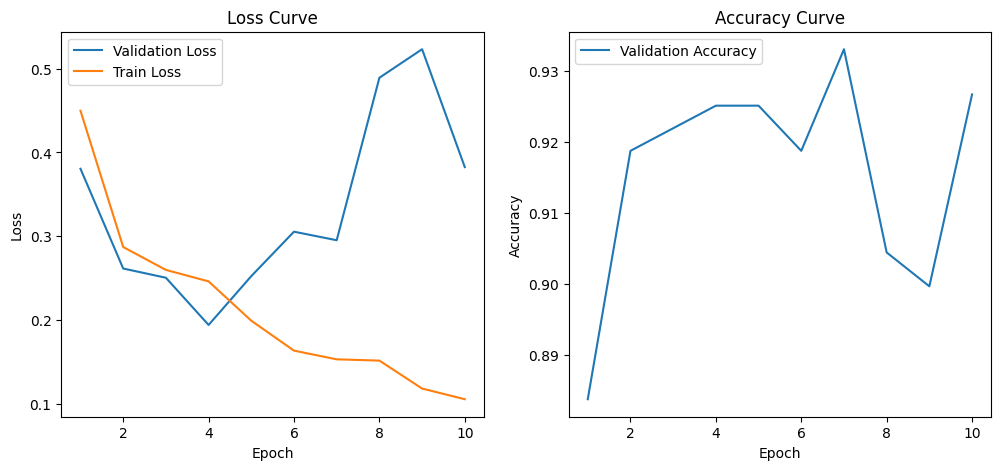

INFO:__main__:Getting predictions...


INFO:__main__:Predictions saved to ./model/predictions_xlm-roberta-base.csv


In [5]:
class Classifier:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained(
            CFG.model_name,
            ignore_mismatched_sizes = True
        )
        self.setup_dir()
        
    @staticmethod
    def setup_dir():
        os.makedirs(CFG.output_dir,exist_ok = True)
        os.makedirs(CFG.checkpoint_dir , exist_ok = True)

    @staticmethod
    def clean_nepali_text(text):
        if pd.isna(text):
            return ""
    
        # 1. Normalize Unicode (Crucial for Nepali)
        text = unicodedata.normalize("NFKC", text)
    
        # 2. Remove URLs and HTML first (before symbols are removed)
        text = re.sub(r"https?://\S+|www\S+", " ", text)
        text = re.sub(r"<[^>]+>", " ", text)
    
        # 3. Remove English letters and Numbers
        text = re.sub(r"[A-Za-z0-9०-९]", " ", text)
    
        # 4. Remove Punctuation and Special Symbols
        # This keeps only Nepali characters and spaces
        text = re.sub(r'[।,!?]', ' ', text)
    
    
        text = re.sub(r"[^\u0900-\u097F\s]", "", text)
    
        # 5. Remove extra spaces
        text = re.sub(r"\s+", " ", text).strip()
    
        # 6. Smart Stopword Removal
        words = text.split()
        cleaned_words = []
        
        for w in words:
            # Check for exact match in stopwords
            if w in stopwords_set:
                continue
                
            # Optional: Remove common suffixes if the word ends with them
            # Note: This is a basic stemmer logic. 
            # for suffix in ['को', 'ले', 'मा', 'लाई', 'भन्दा']:
            #     if w.endswith(suffix) and len(w) > len(suffix):
            #         w = w[:-len(suffix)]
            
            if len(w) > 1:
                cleaned_words.append(w)

        return " ".join(cleaned_words)

    def load_and_clean(self,text_column='text',label_column='label'):
        train_df = pd.read_csv(CFG.train_path)
        test_df = pd.read_csv(CFG.test_path)

        train_df = train_df.drop_duplicates()
        test_df = test_df.drop_duplicates()

        train_df[text_column] = train_df[text_column].apply(self.clean_nepali_text)
        test_df[text_column] = test_df[text_column].apply(self.clean_nepali_text)

        train_df = train_df[[text_column , label_column]]
        test_df = test_df[[text_column , label_column]]

        train_df = train_df.reset_index(drop = True)
        test_df = test_df.reset_index(drop = True)

        return train_df , test_df

    def preprocess_function(self, examples):
        """Tokenize text data"""
        return self.tokenizer(
            examples["text"],
            truncation=True,
            max_length=CFG.max_len,
            padding="max_length"
        )
    def preprocess_data(self, train: pd.DataFrame, test: pd.DataFrame) -> Tuple[DatasetDict, Dataset]:
        """Convert DataFrames to Datasets and preprocess"""
        try:
            # Convert to Dataset format
            train_dataset = Dataset.from_pandas(train)
            test_dataset = Dataset.from_pandas(test)

            # Tokenize datasets
            tok_ds = train_dataset.map(self.preprocess_function, batched=True)
            dds = tok_ds.train_test_split(test_size=CFG.test_size, seed=CFG.random_seed)
            eval_dataset = test_dataset.map(self.preprocess_function, batched=True)

            return dds, eval_dataset
        except Exception as e:
            raise Exception(f"Error in data preprocessing: {e}")
        
    def train(self , dds) -> Trainer:
        try:
            model = AutoModelForSequenceClassification.from_pretrained(
                CFG.model_name,
                num_labels=2,ignore_mismatched_sizes=True
            )
            # for param in model.parameters():
            #     param.requires_grad = False
            
            # # 2. Unfreeze last 5 encoder layers
            # # This works for BERT-like models
            # for layer in model.roberta.encoder.layer[-5:]:
            #     for param in layer.parameters():
            #         param.requires_grad = True
            
            # # 3. Also unfreeze classifier head
            # for param in model.classifier.parameters():
            #     param.requires_grad = True

            # for param in model.roberta.embeddings.parameters():
            #     param.requires_grad = True

            data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer)

            # Set up training arguments
            training_args = TrainingArguments(
                output_dir=CFG.output_dir,
                learning_rate=CFG.learning_rate,
                per_device_train_batch_size=CFG.batch_size,
                per_device_eval_batch_size=CFG.batch_size,
                num_train_epochs=CFG.epochs,
                eval_strategy="epoch",
                save_strategy="epoch",
                logging_strategy = "epoch",
                logging_steps = 1,
                save_total_limit=2,
                fp16=torch.cuda.is_available(),
                logging_dir=f"{CFG.output_dir}/logs",
                load_best_model_at_end=True,
                metric_for_best_model="f1",
            )

            # Initialize trainer
            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=dds['train'],
                eval_dataset=dds['test'],
                # tokenizer=self.tokenizer,
                data_collator=data_collator,
                compute_metrics=self.compute_metrics,
            )
            trainer.train()
            return trainer
        except Exception as e:
            raise Exception(f"Error in model training: {e}")

    def get_predictions(self,trainer:Trainer , eval_dataset:Dataset)->pd.DataFrame:
            predictions = trainer.predict(eval_dataset)
            logits = predictions.predictions
            probabilities = softmax(torch.tensor(logits),dim = -1).numpy()

            # create Dataframe for training ensemble models
            model_name = CFG.model_name.split('/')[-1]
            df_predictions = pd.DataFrame(
                probabilities,
                columns = [f'P0_{model_name}',f'P1_{model_name}']
            )

            return df_predictions

    def get_report(self , trainer:Trainer , eval_dataset:Dataset)->None:
        predictions = trainer.predict(eval_dataset)
        
        logits = predictions.predictions
        probs = softmax(torch.tensor(logits), dim=-1).numpy()
        
        # predicted labels
        y_pred = probs.argmax(axis=1)
        
        # true labels
        y_true = predictions.label_ids
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["human", "ai"])
        
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()
        
        report = classification_report(y_true, y_pred, target_names=["human", "ai"])
        print("\nClassification Report:\n")
        print(report)
        
    def extract_training_history(self, trainer):
        logs = trainer.state.log_history
    
        train_loss = []
        eval_loss = []
        eval_acc = []
        epochs = []
    
        for log in logs:
            if "loss" in log and "epoch" in log:
                train_loss.append(log["loss"])
    
            if "eval_loss" in log:
                eval_loss.append(log["eval_loss"])
                epochs.append(log["epoch"])
    
            if "eval_accuracy" in log:
                eval_acc.append(log["eval_accuracy"])
    
        history = {
            "train_loss": train_loss,
            "eval_loss": eval_loss,
            "eval_acc": eval_acc,
            "epochs": epochs
        }
    
        return history

    def plot_training_curves(self, history):
        epochs = history["epochs"]
    
        plt.figure(figsize=(12, 5))
    
        # Loss curve
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history["eval_loss"], label="Validation Loss")
        plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], label="Train Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss Curve")
        plt.legend()
    
        # Accuracy curve
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["eval_acc"], label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy Curve")
        plt.legend()
    
        plt.show()
        
    @staticmethod
    def compute_metrics(eval_pred) -> Dict[str, float]:
            """Compute evaluation metrics"""
            predictions, labels = eval_pred
            predictions = np.argmax(predictions, axis=1)
        
            metrics = {}
            
            # Accuracy
            accuracy_metric = evaluate.load("accuracy")
            accuracy_result = accuracy_metric.compute(predictions=predictions, references=labels)
            metrics["accuracy"] = accuracy_result["accuracy"]
        
            # Precision
            precision_metric = evaluate.load("precision")
            precision_result = precision_metric.compute(
                predictions=predictions,
                references=labels,
                average="weighted",
                zero_division=0
            )
            metrics["precision"] = precision_result["precision"]
    
             # Recall
            recall_metric = evaluate.load("recall")
            recall_result = recall_metric.compute(
                predictions=predictions,
                references=labels,
                average="weighted",
                zero_division=0
            )
            metrics["recall"] = recall_result["recall"]
        
            # F1 Score
            f1_metric = evaluate.load("f1")
            f1_result = f1_metric.compute(
                predictions=predictions,
                references=labels,
                average="weighted"
            )
            metrics["f1"] = f1_result["f1"]
        
            return metrics
    
def main():
    """Main execution function"""
    try:
        # Initialize trainer
        text_classifier = Classifier()

        # Load and preprocess data
        logger.info("Loading data...")
        train, test = text_classifier.load_and_clean()

        logger.info("Preprocessing data...")
        dds, eval_dataset = text_classifier.preprocess_data(train, test)

        # Train model
        logger.info("Training model...")
        trainer = text_classifier.train(dds)

        logger.info("Plotting loss curves")
        history = text_classifier.extract_training_history(trainer)
        text_classifier.plot_training_curves(history)

        # Get predictions as DataFrame
        logger.info("Getting predictions...")
        df_predictions = text_classifier.get_predictions(trainer, eval_dataset)

        text_classifier.get_report(trainer , eval_dataset)

        # Save predictions DataFrame
        output_path = f"{CFG.output_dir}/predictions_{CFG.model_name.split('/')[-1]}.csv"
        df_predictions.to_csv(output_path, index=False)
        logger.info(f"Predictions saved to {output_path}")

    except Exception as e:
        logger.error(f"Error in main execution:{e}")
        raise

if __name__ == "__main__":
    main()
        

In [7]:
model_path = CFG.output_dir  # same path used in training

model = AutoModelForSequenceClassification.from_pretrained("/kaggle/working/model/checkpoint-1099")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/working/model/checkpoint-1099")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]